#**Total of 6 Cells**
*Hardware : Ibm_kingston*

In [ ]:
!pip install qiskit qiskit-ibm-runtime qiskit-algorithms pylatexenc qiskit-aer
!pip install pandas scikit-learn matplotlib seaborn rdkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 5.2 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=dc1b983c67cec137e0696980ecbe484c1ca44679ec0998b981cedba878d513e0
  Stored in 

#**CELL 1: 10(main qubits) + 2(summary qubits)**

Preparing BBBP Dataset...


Target Backend: ibm_kingston
Running Simulator...
Transpiling circuits for hardware...
Hardware Job Submitted: d6uoq08v5rlc73f46hd0


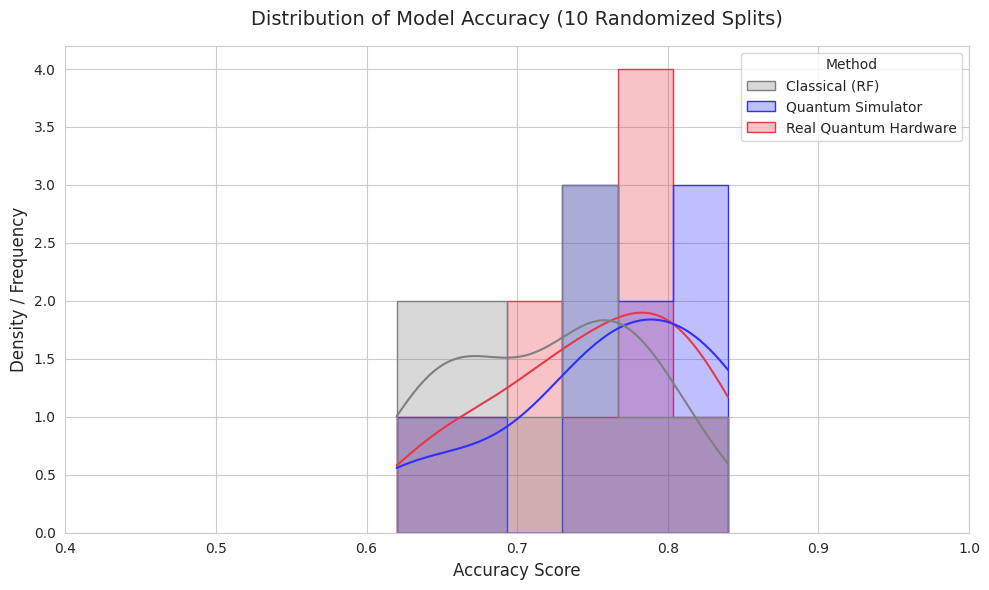


Method                    | Accuracy    | Precision   | Recall      | F1-Score    | AUC-ROC    
-----------------------------------------------------------------------------------------------
Classical (RF)            | 0.72 ± 0.06 | 0.72 ± 0.07 | 0.74 ± 0.08 | 0.73 ± 0.06 | 0.79 ± 0.05
Quantum Simulator         | 0.76 ± 0.07 | 0.77 ± 0.09 | 0.74 ± 0.08 | 0.76 ± 0.07 | 0.83 ± 0.08
Real Quantum Hardware     | 0.75 ± 0.07 | 0.76 ± 0.09 | 0.75 ± 0.07 | 0.75 ± 0.06 | 0.79 ± 0.07


In [ ]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from rdkit.Chem import AllChem

# Qiskit Imports
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
EN_MAP = {'H': 2.20, 'Li': 0.98, 'Be': 1.57, 'B': 2.04, 'C': 2.55,
          'N': 3.04, 'O': 3.44, 'F': 3.98, 'S': 2.58, 'Cl': 3.16}

ALPHA = 0.1

N_QUBITS = 12
SHOTS = 8192
N_SPLITS = 10


# --- CORE FUNCTIONS ---
def qmse_hero_normal(smiles):

    n_qubits = 12
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return QuantumCircuit(n_qubits)

    atoms = [a for a in mol.GetAtoms()]
    qc = QuantumCircuit(n_qubits)

    # --- 1. BACKBONE ENCODING (Exact Atomic Mapping) ---
    # θᵢ = α · χᵢ²  for i ∈ {0, …, 9}
    n_exact = 10
    backbone = atoms[:n_exact]
    tail = atoms[n_exact:]
    mol_to_qubit = {atom.GetIdx(): i for i, atom in enumerate(backbone)}

    for atom in backbone:
        en = EN_MAP.get(atom.GetSymbol(), 1.0)
        qc.ry(ALPHA * (en ** 2), mol_to_qubit[atom.GetIdx()])

    # --- 2. TAIL SUMMARY ENCODING (Alternating Dimensional Compression) ---
    # θ₁₀ = (α/2) · Σχₐ   (set A: even-indexed tail atoms)
    # θ₁₁ = (α/2) · Σχᵦ   (set B: odd-indexed tail atoms)
    if tail:
        tail_A = tail[0::2]
        tail_B = tail[1::2]
        if tail_A:
            qc.ry((ALPHA / 2) * sum(EN_MAP.get(a.GetSymbol(), 1.0) for a in tail_A), 10)
        if tail_B:
            qc.ry((ALPHA / 2) * sum(EN_MAP.get(a.GetSymbol(), 1.0) for a in tail_B), 11)

    # --- 3. TOPOLOGICAL ENTANGLEMENT (Bond Architecture) ---
    # ϕᵢⱼ = wᵢⱼ / 2  applied uniformly to ALL bond cases
    for bond in mol.GetBonds():
        idx1, idx2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        q1, q2 = mol_to_qubit.get(idx1), mol_to_qubit.get(idx2)

        b_type = bond.GetBondTypeAsDouble()
        phi_ij = b_type / 2

        if q1 is not None and q2 is not None:
            # Backbone ↔ backbone: direct entanglement
            qc.rxx(phi_ij, q1, q2)
        elif q1 is not None:
            # Backbone → tail: symmetrically distributed to both summary qubits
            qc.rxx(phi_ij, q1, 10)
            qc.rxx(phi_ij, q1, 11)
        elif q2 is not None:
            # Tail → backbone: symmetrically distributed to both summary qubits
            qc.rxx(phi_ij, q2, 10)
            qc.rxx(phi_ij, q2, 11)

    qc.measure_all()
    return qc


def extract_features(pub_result, n_qubits=12):
    counts = pub_result.data.meas.get_counts()
    p = np.zeros(2 ** n_qubits)
    tot = sum(counts.values())
    for k, v in counts.items():
        idx = int(k, 2) if isinstance(k, str) else k
        if idx < len(p):
            p[idx] = v / tot
    return p


# --- 1. DATA PREPARATION ---
print("Preparing BBBP Dataset...")
df = pd.read_csv("https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv")
df = df.dropna(subset=['p_np', 'smiles'])
df = df[df['smiles'].apply(
    lambda s: Chem.MolFromSmiles(s) is not None and len(s) < 70
)]

n_sub = 125
df_final = pd.concat([
    df[df['p_np'] == 1].sample(n_sub, random_state=42),
    df[df['p_np'] == 0].sample(n_sub, random_state=42)
]).sample(frac=1, random_state=42)

y = df_final['p_np'].values
smiles_list = df_final['smiles'].values
circuits = [qmse_hero_normal(s) for s in smiles_list]

# --- 2. HARDWARE INITIALIZATION ---
token = "API"
instance = "CRN"
try:
    QiskitRuntimeService.save_account(
        token=token, channel="ibm_cloud",
        instance=instance, name="Name", overwrite=True
    )
except:
    pass

service = QiskitRuntimeService(name="Name")
backend = service.backend("ibm_kingston")
print(f"Target Backend: {backend.name}")

# --- 3. FEATURE EXTRACTION ---

# A. Simulator
print("Running Simulator...")
aer_sampler = AerSampler()
X_sim = np.array([
    extract_features(p)
    for p in aer_sampler.run([(c,) for c in circuits], shots=SHOTS).result()
])

# B. Hardware (all circuits submitted as one job)
print("Transpiling circuits for hardware...")
pm = generate_preset_pass_manager(backend=backend, optimization_level=1, seed_transpiler=42)
isa_circuits = pm.run(circuits)
hw_sampler = RuntimeSampler(mode=backend)
hw_job = hw_sampler.run([(c,) for c in isa_circuits], shots=SHOTS)
print(f"Hardware Job Submitted: {hw_job.job_id()}")
X_hw = np.array([extract_features(pub) for pub in hw_job.result()])

# C. Classical (256-bit radius-2 Morgan fingerprints / ECFP4)
X_class = np.array([
    np.array(AllChem.GetMorganFingerprintAsBitVect(
        Chem.MolFromSmiles(s), 2, nBits=256
    ))
    for s in smiles_list
])

# --- 4. 10-SPLIT ANALYSIS ---
sss = StratifiedShuffleSplit(n_splits=N_SPLITS, test_size=0.2, random_state=42)
results_list = []

for i, (train_idx, test_idx) in enumerate(sss.split(X_class, y)):
    y_test = y[test_idx]

    # Classical — Random Forest
    clf_c = RandomForestClassifier(n_estimators=100).fit(X_class[train_idx], y[train_idx])
    y_pred_c = clf_c.predict(X_class[test_idx])
    y_prob_c = clf_c.predict_proba(X_class[test_idx])[:, 1]
    results_list.append({
        'Split': i, 'Method': 'Classical (RF)',
        'Accuracy':  accuracy_score(y_test, y_pred_c),
        'Precision': precision_score(y_test, y_pred_c, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_c, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred_c, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_c)
    })

    # Quantum Simulator — SVM RBF
    sc_s = StandardScaler()
    clf_s = SVC(kernel='rbf', C=10, probability=True).fit(
        sc_s.fit_transform(X_sim[train_idx]), y[train_idx]
    )
    X_sim_test = sc_s.transform(X_sim[test_idx])
    y_pred_s = clf_s.predict(X_sim_test)
    y_prob_s = clf_s.predict_proba(X_sim_test)[:, 1]
    results_list.append({
        'Split': i, 'Method': 'Quantum Simulator',
        'Accuracy':  accuracy_score(y_test, y_pred_s),
        'Precision': precision_score(y_test, y_pred_s, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_s, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred_s, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_s)
    })

    # Real Quantum Hardware — SVM RBF
    sc_h = StandardScaler()
    clf_h = SVC(kernel='rbf', C=10, probability=True).fit(
        sc_h.fit_transform(X_hw[train_idx]), y[train_idx]
    )
    X_hw_test = sc_h.transform(X_hw[test_idx])
    y_pred_h = clf_h.predict(X_hw_test)
    y_prob_h = clf_h.predict_proba(X_hw_test)[:, 1]
    results_list.append({
        'Split': i, 'Method': 'Real Quantum Hardware',
        'Accuracy':  accuracy_score(y_test, y_pred_h),
        'Precision': precision_score(y_test, y_pred_h, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_h, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred_h, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_h)
    })

# --- 5. VISUALIZATION ---
df_plot = pd.DataFrame(results_list)

palette = {
    'Classical (RF)':       '#7f7f7f',
    'Quantum Simulator':    '#2e2eff',
    'Real Quantum Hardware': '#e63946'
}

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.histplot(
    data=df_plot, x='Accuracy', hue='Method',
    kde=True, element="step", palette=palette, alpha=0.3
)
plt.title('Distribution of Model Accuracy (10 Randomized Splits)', fontsize=14, pad=15)
plt.xlabel('Accuracy Score', fontsize=12)
plt.ylabel('Density / Frequency', fontsize=12)
plt.xlim(0.4, 1.0)
plt.tight_layout()
plt.show()

# --- 6. TABLE---
print("\n" + "=" * 95)
print(f"{'Method':25} | {'Accuracy':11} | {'Precision':11} | {'Recall':11} | {'F1-Score':11} | {'AUC-ROC':11}")
print("-" * 95)
for m in df_plot['Method'].unique():
    subset = df_plot[df_plot['Method'] == m]
    acc_str  = f"{subset['Accuracy'].mean():.2f} ± {subset['Accuracy'].std():.2f}"
    prec_str = f"{subset['Precision'].mean():.2f} ± {subset['Precision'].std():.2f}"
    rec_str  = f"{subset['Recall'].mean():.2f} ± {subset['Recall'].std():.2f}"
    f1_str   = f"{subset['F1-Score'].mean():.2f} ± {subset['F1-Score'].std():.2f}"
    auc_str  = f"{subset['AUC-ROC'].mean():.2f} ± {subset['AUC-ROC'].std():.2f}"
    print(f"{m:25} | {acc_str:11} | {prec_str:11} | {rec_str:11} | {f1_str:11} | {auc_str:11}")
print("=" * 95)

#**CELL 2: 10(main qubits) + 4(summary qubits)**

Preparing BBBP Dataset (10+4 configuration)...


Target Backend: ibm_kingston
Running Simulator...
Transpiling circuits for hardware...
Hardware Job Submitted: d6uhsjgv5rlc73f3vf8g


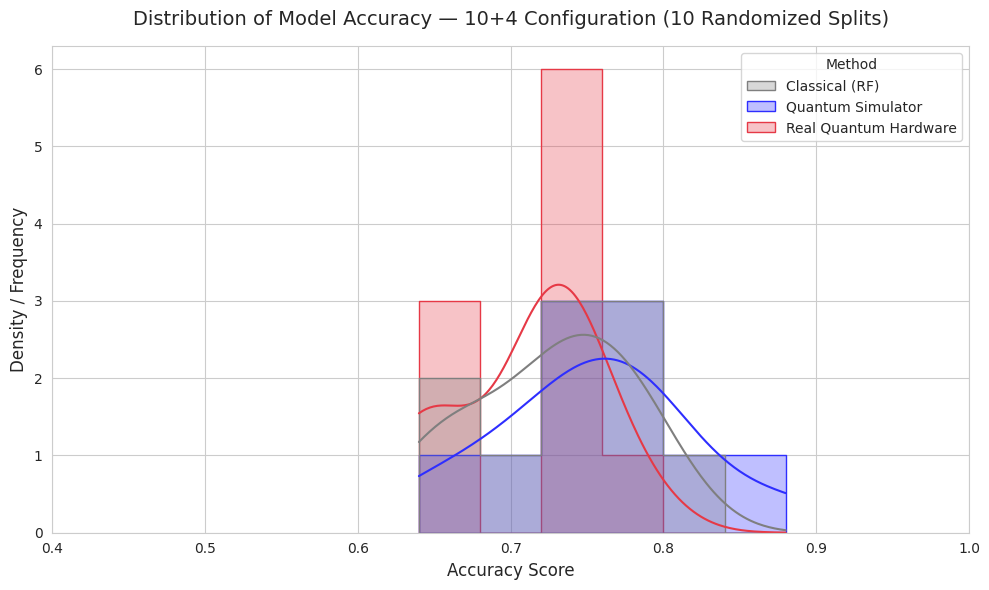


  Configuration: 10+4  |  N_QUBITS=14  |  Feature Vector Dim=2^14=16384
Method                    | Accuracy    | Precision   | Recall      | F1-Score    | AUC-ROC    
-----------------------------------------------------------------------------------------------
Classical (RF)            | 0.73 ± 0.05 | 0.72 ± 0.06 | 0.74 ± 0.09 | 0.73 ± 0.06 | 0.79 ± 0.06
Quantum Simulator         | 0.75 ± 0.07 | 0.77 ± 0.07 | 0.73 ± 0.10 | 0.75 ± 0.07 | 0.78 ± 0.07
Real Quantum Hardware     | 0.71 ± 0.05 | 0.76 ± 0.08 | 0.64 ± 0.13 | 0.68 ± 0.08 | 0.75 ± 0.07


In [ ]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from rdkit.Chem import AllChem

# Qiskit Imports
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
EN_MAP = {'H': 2.20, 'Li': 0.98, 'Be': 1.57, 'B': 2.04, 'C': 2.55,
          'N': 3.04, 'O': 3.44, 'F': 3.98, 'S': 2.58, 'Cl': 3.16}

ALPHA    = 0.1

# 10 backbone + 4 summary = 14 qubits total
N_EXACT   = 10
N_SUMMARY = 4
N_QUBITS  = N_EXACT + N_SUMMARY   # 14

SHOTS    = 8192
N_SPLITS = 10


# --- CORE FUNCTIONS ---
def qmse_10_plus_4(smiles):
    """
    QMSE feature map with 10+4 qubit allocation.
    - 10 backbone qubits (qubits 0–9): exact atomic mapping, θᵢ = α · χᵢ²
    - 4 summary qubits (qubits 10–13): alternating tail compression, θ = (α/2) · Σχ
    - Entanglement: ϕᵢⱼ = wᵢⱼ/2 applied uniformly to all bond cases
    Feature vector dimension: 2^14 = 16384
    """
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return QuantumCircuit(N_QUBITS)

    atoms = list(mol.GetAtoms())
    qc    = QuantumCircuit(N_QUBITS)

    # --- 1. BACKBONE ENCODING (Exact Atomic Mapping) ---
    # θᵢ = α · χᵢ²  for i ∈ {0, …, 9}
    backbone     = atoms[:N_EXACT]
    tail         = atoms[N_EXACT:]
    mol_to_qubit = {atom.GetIdx(): i for i, atom in enumerate(backbone)}

    for atom in backbone:
        en = EN_MAP.get(atom.GetSymbol(), 1.0)
        qc.ry(ALPHA * (en ** 2), mol_to_qubit[atom.GetIdx()])

    # --- 2. TAIL SUMMARY ENCODING (4-way Alternating Compression) ---
    # tail atoms distributed across 4 summary qubits
    # instead of 2, using the same modulo-based alternating split.
    # k receives tail atoms at indices: k, k+4, k+8, …
    # θ_{10+k} = (α/2) · Σχ for atoms in set k,  k ∈ {0,1,2,3}
    if tail:
        tail_sets = [[] for _ in range(N_SUMMARY)]
        for idx, atom in enumerate(tail):
            tail_sets[idx % N_SUMMARY].append(atom)

        for s_idx, t_set in enumerate(tail_sets):
            if t_set:
                agg_en = sum(EN_MAP.get(a.GetSymbol(), 1.0) for a in t_set)
                qc.ry((ALPHA / 2) * agg_en, N_EXACT + s_idx)

    # --- 3. TOPOLOGICAL ENTANGLEMENT (Bond Architecture) ---
    # ϕᵢⱼ = wᵢⱼ/2 applied uniformly to ALL bond cases —
    # backbone→tail bonds fan out to ALL 4 summary qubits
    # (is 2 summary qubits in 10+2)
    summary_qubits = list(range(N_EXACT, N_QUBITS))   # [10, 11, 12, 13]

    for bond in mol.GetBonds():
        idx1, idx2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        q1, q2     = mol_to_qubit.get(idx1), mol_to_qubit.get(idx2)
        phi_ij     = bond.GetBondTypeAsDouble() / 2

        if q1 is not None and q2 is not None:
            # Backbone ↔ backbone: direct entanglement
            qc.rxx(phi_ij, q1, q2)
        elif q1 is not None:
            # Backbone → tail: symmetrically distributed to ALL 4 summary qubits
            for sq in summary_qubits:
                qc.rxx(phi_ij, q1, sq)
        elif q2 is not None:
            # Tail → backbone: symmetrically distributed to ALL 4 summary qubits
            for sq in summary_qubits:
                qc.rxx(phi_ij, q2, sq)

    qc.measure_all()
    return qc


def extract_features(pub_result, n_qubits=N_QUBITS):
    # default n_qubits=14, producing 2^14 = 16384-dim vector
    counts = pub_result.data.meas.get_counts()
    p      = np.zeros(2 ** n_qubits)
    tot    = sum(counts.values())
    for k, v in counts.items():
        idx = int(k, 2) if isinstance(k, str) else k
        if idx < len(p):
            p[idx] = v / tot
    return p


# --- 1. DATA PREPARATION ---
print("Preparing BBBP Dataset (10+4 configuration)...")
df = pd.read_csv("https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv")
df = df.dropna(subset=['p_np', 'smiles'])
df = df[df['smiles'].apply(
    lambda s: Chem.MolFromSmiles(s) is not None and len(s) < 70
)]

n_sub    = 125
df_final = pd.concat([
    df[df['p_np'] == 1].sample(n_sub, random_state=42),
    df[df['p_np'] == 0].sample(n_sub, random_state=42)
]).sample(frac=1, random_state=42)

y          = df_final['p_np'].values
smiles_list = df_final['smiles'].values
circuits   = [qmse_10_plus_4(s) for s in smiles_list]

# --- 2. HARDWARE INITIALIZATION ---
token    = "API"
instance = "CRN"
try:
    QiskitRuntimeService.save_account(
        token=token, channel="ibm_cloud",
        instance=instance, name="Name", overwrite=True
    )
except:
    pass

service = QiskitRuntimeService(name="Name")
backend = service.backend("ibm_kingston")
print(f"Target Backend: {backend.name}")

# --- 3. FEATURE EXTRACTION ---

# A. Simulator
print("Running Simulator...")
aer_sampler = AerSampler()
X_sim = np.array([
    extract_features(p)
    for p in aer_sampler.run([(c,) for c in circuits], shots=SHOTS).result()
])

# B. Hardware (all 250 circuits submitted as one job)
print("Transpiling circuits for hardware...")
pm          = generate_preset_pass_manager(backend=backend, optimization_level=1, seed_transpiler=42)
isa_circuits = pm.run(circuits)
hw_sampler  = RuntimeSampler(mode=backend)
hw_job      = hw_sampler.run([(c,) for c in isa_circuits], shots=SHOTS)
print(f"Hardware Job Submitted: {hw_job.job_id()}")
X_hw = np.array([extract_features(pub) for pub in hw_job.result()])

# C. Classical (256-bit radius-2 Morgan fingerprints / ECFP4)
X_class = np.array([
    np.array(AllChem.GetMorganFingerprintAsBitVect(
        Chem.MolFromSmiles(s), 2, nBits=256
    ))
    for s in smiles_list
])

# --- 4. 10-SPLIT ANALYSIS ---
sss          = StratifiedShuffleSplit(n_splits=N_SPLITS, test_size=0.2, random_state=42)
results_list = []

for i, (train_idx, test_idx) in enumerate(sss.split(X_class, y)):
    y_test = y[test_idx]

    # Classical — Random Forest
    clf_c   = RandomForestClassifier(n_estimators=100).fit(X_class[train_idx], y[train_idx])
    y_pred_c = clf_c.predict(X_class[test_idx])
    y_prob_c = clf_c.predict_proba(X_class[test_idx])[:, 1]
    results_list.append({
        'Split': i, 'Method': 'Classical (RF)',
        'Accuracy':  accuracy_score(y_test, y_pred_c),
        'Precision': precision_score(y_test, y_pred_c, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_c, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred_c, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_c)
    })

    # Quantum Simulator — SVM RBF
    sc_s    = StandardScaler()
    clf_s   = SVC(kernel='rbf', C=10, probability=True).fit(
        sc_s.fit_transform(X_sim[train_idx]), y[train_idx]
    )
    X_sim_test = sc_s.transform(X_sim[test_idx])
    y_pred_s   = clf_s.predict(X_sim_test)
    y_prob_s   = clf_s.predict_proba(X_sim_test)[:, 1]
    results_list.append({
        'Split': i, 'Method': 'Quantum Simulator',
        'Accuracy':  accuracy_score(y_test, y_pred_s),
        'Precision': precision_score(y_test, y_pred_s, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_s, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred_s, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_s)
    })

    # Real Quantum Hardware — SVM RBF
    sc_h    = StandardScaler()
    clf_h   = SVC(kernel='rbf', C=10, probability=True).fit(
        sc_h.fit_transform(X_hw[train_idx]), y[train_idx]
    )
    X_hw_test = sc_h.transform(X_hw[test_idx])
    y_pred_h  = clf_h.predict(X_hw_test)
    y_prob_h  = clf_h.predict_proba(X_hw_test)[:, 1]
    results_list.append({
        'Split': i, 'Method': 'Real Quantum Hardware',
        'Accuracy':  accuracy_score(y_test, y_pred_h),
        'Precision': precision_score(y_test, y_pred_h, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_h, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred_h, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_h)
    })

# --- 5. VISUALIZATION ---
df_plot = pd.DataFrame(results_list)

palette = {
    'Classical (RF)':        '#7f7f7f',
    'Quantum Simulator':     '#2e2eff',
    'Real Quantum Hardware':  '#e63946'
}

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.histplot(
    data=df_plot, x='Accuracy', hue='Method',
    kde=True, element="step", palette=palette, alpha=0.3
)
plt.title('Distribution of Model Accuracy — 10+4 Configuration (10 Randomized Splits)',
          fontsize=14, pad=15)
plt.xlabel('Accuracy Score', fontsize=12)
plt.ylabel('Density / Frequency', fontsize=12)
plt.xlim(0.4, 1.0)
plt.tight_layout()
plt.show()

# --- 6. Table ---
print("\n" + "=" * 95)
print(f"  Configuration: 10+4  |  N_QUBITS={N_QUBITS}  |  Feature Vector Dim=2^{N_QUBITS}={2**N_QUBITS}")
print("=" * 95)
print(f"{'Method':25} | {'Accuracy':11} | {'Precision':11} | {'Recall':11} | {'F1-Score':11} | {'AUC-ROC':11}")
print("-" * 95)
for m in df_plot['Method'].unique():
    subset   = df_plot[df_plot['Method'] == m]
    acc_str  = f"{subset['Accuracy'].mean():.2f} ± {subset['Accuracy'].std():.2f}"
    prec_str = f"{subset['Precision'].mean():.2f} ± {subset['Precision'].std():.2f}"
    rec_str  = f"{subset['Recall'].mean():.2f} ± {subset['Recall'].std():.2f}"
    f1_str   = f"{subset['F1-Score'].mean():.2f} ± {subset['F1-Score'].std():.2f}"
    auc_str  = f"{subset['AUC-ROC'].mean():.2f} ± {subset['AUC-ROC'].std():.2f}"
    print(f"{m:25} | {acc_str:11} | {prec_str:11} | {rec_str:11} | {f1_str:11} | {auc_str:11}")
print("=" * 95)

#**CELL 3: 12(main qubits) + 2(summary qubits)**

Preparing BBBP Dataset (12+2 configuration)...


Target Backend: ibm_kingston
Running Simulator...
Transpiling circuits for hardware...
Hardware Job Submitted: d6up2nqf84ks73deh5sg


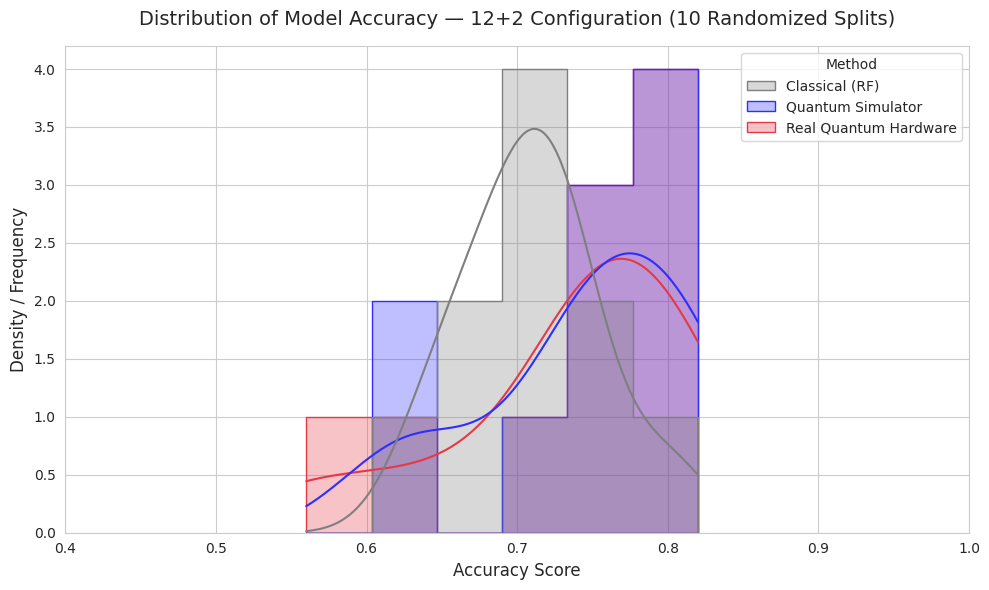


  Configuration: 12+2  |  N_QUBITS=14  |  Feature Vector Dim=2^14=16384
Method                    | Accuracy    | Precision   | Recall      | F1-Score    | AUC-ROC    
-----------------------------------------------------------------------------------------------
Classical (RF)            | 0.71 ± 0.05 | 0.71 ± 0.06 | 0.72 ± 0.08 | 0.71 ± 0.05 | 0.78 ± 0.06
Quantum Simulator         | 0.75 ± 0.07 | 0.79 ± 0.09 | 0.68 ± 0.08 | 0.73 ± 0.07 | 0.79 ± 0.07
Real Quantum Hardware     | 0.74 ± 0.08 | 0.76 ± 0.10 | 0.70 ± 0.08 | 0.73 ± 0.08 | 0.76 ± 0.08


In [ ]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from rdkit.Chem import AllChem

# Qiskit Imports
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
EN_MAP = {'H': 2.20, 'Li': 0.98, 'Be': 1.57, 'B': 2.04, 'C': 2.55,
          'N': 3.04, 'O': 3.44, 'F': 3.98, 'S': 2.58, 'Cl': 3.16}

ALPHA     = 0.1

#12 backbone + 2 summary = 14 qubits total
N_EXACT   = 12
N_SUMMARY = 2
N_QUBITS  = N_EXACT + N_SUMMARY   # 14

SHOTS    = 8192
N_SPLITS = 10


# --- CORE FUNCTIONS ---
def qmse_12_plus_2(smiles):
    """
    QMSE feature map with 12+2 qubit allocation.
    - 12 backbone qubits (qubits 0–11): exact atomic mapping, θᵢ = α · χᵢ²
    - 2 summary qubits (qubits 12–13): alternating tail compression, θ = (α/2) · Σχ
    - Entanglement: ϕᵢⱼ = wᵢⱼ/2 applied uniformly to all bond cases
    Feature vector dimension: 2^14 = 16384
    """
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return QuantumCircuit(N_QUBITS)

    atoms = list(mol.GetAtoms())
    qc    = QuantumCircuit(N_QUBITS)

    # --- 1. BACKBONE ENCODING (Exact Atomic Mapping) ---
    # θᵢ = α · χᵢ²  for i ∈ {0, …, 11}
    # first 12 atoms instead of 10
    backbone     = atoms[:N_EXACT]
    tail         = atoms[N_EXACT:]
    mol_to_qubit = {atom.GetIdx(): i for i, atom in enumerate(backbone)}

    for atom in backbone:
        en = EN_MAP.get(atom.GetSymbol(), 1.0)
        qc.ry(ALPHA * (en ** 2), mol_to_qubit[atom.GetIdx()])

    # --- 2. TAIL SUMMARY ENCODING (2-way Alternating Compression) ---
    # Tail atoms beyond position 12 split into alternating sets A and B
    # θ₁₂ = (α/2) · Σχₐ   (set A: even-indexed tail atoms → qubit 12)
    # θ₁₃ = (α/2) · Σχᵦ   (set B: odd-indexed tail atoms  → qubit 13)
    if tail:
        tail_sets = [[] for _ in range(N_SUMMARY)]
        for idx, atom in enumerate(tail):
            tail_sets[idx % N_SUMMARY].append(atom)

        for s_idx, t_set in enumerate(tail_sets):
            if t_set:
                agg_en = sum(EN_MAP.get(a.GetSymbol(), 1.0) for a in t_set)
                qc.ry((ALPHA / 2) * agg_en, N_EXACT + s_idx)

    # --- 3. TOPOLOGICAL ENTANGLEMENT (Bond Architecture) ---
    # ϕᵢⱼ = wᵢⱼ/2 applied uniformly to ALL bond cases
    # summary qubits are 12 and 13 (not 10 and 11 )
    summary_qubits = list(range(N_EXACT, N_QUBITS))   # [12, 13]

    for bond in mol.GetBonds():
        idx1, idx2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        q1, q2     = mol_to_qubit.get(idx1), mol_to_qubit.get(idx2)
        phi_ij     = bond.GetBondTypeAsDouble() / 2

        if q1 is not None and q2 is not None:
            # Backbone ↔ backbone: direct entanglement
            qc.rxx(phi_ij, q1, q2)
        elif q1 is not None:
            # Backbone → tail: symmetrically distributed to both summary qubits
            for sq in summary_qubits:
                qc.rxx(phi_ij, q1, sq)
        elif q2 is not None:
            # Tail → backbone: symmetrically distributed to both summary qubits
            for sq in summary_qubits:
                qc.rxx(phi_ij, q2, sq)

    qc.measure_all()
    return qc


def extract_features(pub_result, n_qubits=N_QUBITS):
    # default n_qubits=14, producing 2^14 = 16384-dim vector
    counts = pub_result.data.meas.get_counts()
    p      = np.zeros(2 ** n_qubits)
    tot    = sum(counts.values())
    for k, v in counts.items():
        idx = int(k, 2) if isinstance(k, str) else k
        if idx < len(p):
            p[idx] = v / tot
    return p


# --- 1. DATA PREPARATION ---
print("Preparing BBBP Dataset (12+2 configuration)...")
df = pd.read_csv("https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv")
df = df.dropna(subset=['p_np', 'smiles'])
df = df[df['smiles'].apply(
    lambda s: Chem.MolFromSmiles(s) is not None and len(s) < 70
)]

n_sub    = 125
df_final = pd.concat([
    df[df['p_np'] == 1].sample(n_sub, random_state=42),
    df[df['p_np'] == 0].sample(n_sub, random_state=42)
]).sample(frac=1, random_state=42)

y           = df_final['p_np'].values
smiles_list = df_final['smiles'].values
circuits    = [qmse_12_plus_2(s) for s in smiles_list]

# --- 2. HARDWARE INITIALIZATION ---
token    = "API"
instance = "CRN"
try:
    QiskitRuntimeService.save_account(
        token=token, channel="ibm_cloud",
        instance=instance, name="Name", overwrite=True
    )
except:
    pass

service = QiskitRuntimeService(name="Name")
backend = service.backend("ibm_kingston")
print(f"Target Backend: {backend.name}")

# --- 3. FEATURE EXTRACTION ---

# A. Simulator
print("Running Simulator...")
aer_sampler = AerSampler()
X_sim = np.array([
    extract_features(p)
    for p in aer_sampler.run([(c,) for c in circuits], shots=SHOTS).result()
])

# B. Hardware (all 250 circuits submitted as one job)
print("Transpiling circuits for hardware...")
pm           = generate_preset_pass_manager(backend=backend, optimization_level=1, seed_transpiler=42)
isa_circuits = pm.run(circuits)
hw_sampler   = RuntimeSampler(mode=backend)
hw_job       = hw_sampler.run([(c,) for c in isa_circuits], shots=SHOTS)
print(f"Hardware Job Submitted: {hw_job.job_id()}")
X_hw = np.array([extract_features(pub) for pub in hw_job.result()])

# C. Classical (256-bit radius-2 Morgan fingerprints / ECFP4)
X_class = np.array([
    np.array(AllChem.GetMorganFingerprintAsBitVect(
        Chem.MolFromSmiles(s), 2, nBits=256
    ))
    for s in smiles_list
])

# --- 4. 10-SPLIT ANALYSIS ---
sss          = StratifiedShuffleSplit(n_splits=N_SPLITS, test_size=0.2, random_state=42)
results_list = []

for i, (train_idx, test_idx) in enumerate(sss.split(X_class, y)):
    y_test = y[test_idx]

    # Classical — Random Forest
    clf_c    = RandomForestClassifier(n_estimators=100).fit(X_class[train_idx], y[train_idx])
    y_pred_c = clf_c.predict(X_class[test_idx])
    y_prob_c = clf_c.predict_proba(X_class[test_idx])[:, 1]
    results_list.append({
        'Split': i, 'Method': 'Classical (RF)',
        'Accuracy':  accuracy_score(y_test, y_pred_c),
        'Precision': precision_score(y_test, y_pred_c, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_c, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred_c, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_c)
    })

    # Quantum Simulator — SVM RBF
    sc_s     = StandardScaler()
    clf_s    = SVC(kernel='rbf', C=10, probability=True).fit(
        sc_s.fit_transform(X_sim[train_idx]), y[train_idx]
    )
    X_sim_test = sc_s.transform(X_sim[test_idx])
    y_pred_s   = clf_s.predict(X_sim_test)
    y_prob_s   = clf_s.predict_proba(X_sim_test)[:, 1]
    results_list.append({
        'Split': i, 'Method': 'Quantum Simulator',
        'Accuracy':  accuracy_score(y_test, y_pred_s),
        'Precision': precision_score(y_test, y_pred_s, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_s, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred_s, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_s)
    })

    # Real Quantum Hardware — SVM RBF
    sc_h     = StandardScaler()
    clf_h    = SVC(kernel='rbf', C=10, probability=True).fit(
        sc_h.fit_transform(X_hw[train_idx]), y[train_idx]
    )
    X_hw_test = sc_h.transform(X_hw[test_idx])
    y_pred_h  = clf_h.predict(X_hw_test)
    y_prob_h  = clf_h.predict_proba(X_hw_test)[:, 1]
    results_list.append({
        'Split': i, 'Method': 'Real Quantum Hardware',
        'Accuracy':  accuracy_score(y_test, y_pred_h),
        'Precision': precision_score(y_test, y_pred_h, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_h, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred_h, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_h)
    })

# --- 5. VISUALIZATION ---
df_plot = pd.DataFrame(results_list)

palette = {
    'Classical (RF)':        '#7f7f7f',
    'Quantum Simulator':     '#2e2eff',
    'Real Quantum Hardware':  '#e63946'
}

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.histplot(
    data=df_plot, x='Accuracy', hue='Method',
    kde=True, element="step", palette=palette, alpha=0.3
)
plt.title('Distribution of Model Accuracy — 12+2 Configuration (10 Randomized Splits)',
          fontsize=14, pad=15)
plt.xlabel('Accuracy Score', fontsize=12)
plt.ylabel('Density / Frequency', fontsize=12)
plt.xlim(0.4, 1.0)
plt.tight_layout()
plt.show()

# --- 6. Table ---
print("\n" + "=" * 95)
print(f"  Configuration: 12+2  |  N_QUBITS={N_QUBITS}  |  Feature Vector Dim=2^{N_QUBITS}={2**N_QUBITS}")
print("=" * 95)
print(f"{'Method':25} | {'Accuracy':11} | {'Precision':11} | {'Recall':11} | {'F1-Score':11} | {'AUC-ROC':11}")
print("-" * 95)
for m in df_plot['Method'].unique():
    subset   = df_plot[df_plot['Method'] == m]
    acc_str  = f"{subset['Accuracy'].mean():.2f} ± {subset['Accuracy'].std():.2f}"
    prec_str = f"{subset['Precision'].mean():.2f} ± {subset['Precision'].std():.2f}"
    rec_str  = f"{subset['Recall'].mean():.2f} ± {subset['Recall'].std():.2f}"
    f1_str   = f"{subset['F1-Score'].mean():.2f} ± {subset['F1-Score'].std():.2f}"
    auc_str  = f"{subset['AUC-ROC'].mean():.2f} ± {subset['AUC-ROC'].std():.2f}"
    print(f"{m:25} | {acc_str:11} | {prec_str:11} | {rec_str:11} | {f1_str:11} | {auc_str:11}")
print("=" * 95)

#**CELL 4: 12(main qubits) + 4(summary qubits)**

Preparing BBBP Dataset (12+4 configuration)...


Target Backend: ibm_kingston
Running Simulator...
Transpiling circuits for hardware...
Hardware Job Submitted: d6uiaiov5rlc73f3vu9g


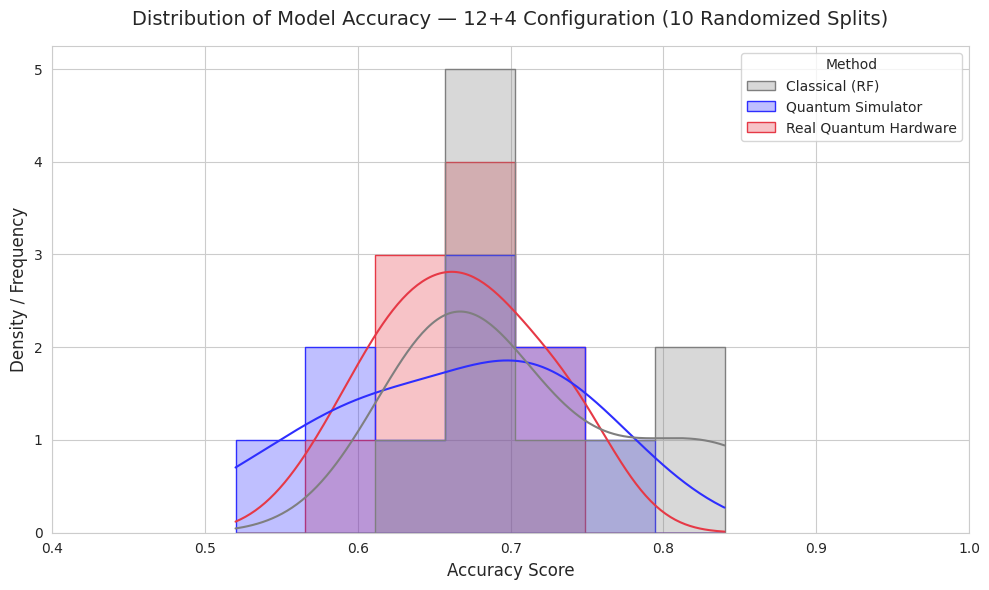


  Configuration: 12+4  |  N_QUBITS=16  |  Feature Vector Dim=2^16=65536
Method                    | Accuracy    | Precision   | Recall      | F1-Score    | AUC-ROC    
-----------------------------------------------------------------------------------------------
Classical (RF)            | 0.71 ± 0.08 | 0.71 ± 0.08 | 0.72 ± 0.11 | 0.71 ± 0.08 | 0.78 ± 0.07
Quantum Simulator         | 0.66 ± 0.08 | 0.74 ± 0.12 | 0.50 ± 0.12 | 0.59 ± 0.11 | 0.73 ± 0.06
Real Quantum Hardware     | 0.67 ± 0.05 | 0.75 ± 0.09 | 0.51 ± 0.08 | 0.60 ± 0.07 | 0.60 ± 0.19


In [ ]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from rdkit.Chem import AllChem

# Qiskit Imports
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
EN_MAP = {'H': 2.20, 'Li': 0.98, 'Be': 1.57, 'B': 2.04, 'C': 2.55,
          'N': 3.04, 'O': 3.44, 'F': 3.98, 'S': 2.58, 'Cl': 3.16}

ALPHA     = 0.1

# 12 backbone + 4 summary = 16 qubits total
N_EXACT   = 12
N_SUMMARY = 4
N_QUBITS  = N_EXACT + N_SUMMARY   # 16

SHOTS    = 8192
N_SPLITS = 10


# --- CORE FUNCTIONS ---
def qmse_12_plus_4(smiles):
    """
    QMSE feature map with 12+4 qubit allocation.
    - 12 backbone qubits (qubits 0–11): exact atomic mapping, θᵢ = α · χᵢ²
    - 4 summary qubits (qubits 12–15): 4-way alternating tail compression, θ = (α/2) · Σχ
    - Entanglement: ϕᵢⱼ = wᵢⱼ/2 applied uniformly to all bond cases
    Feature vector dimension: 2^16 = 65536
    """
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return QuantumCircuit(N_QUBITS)

    atoms = list(mol.GetAtoms())
    qc    = QuantumCircuit(N_QUBITS)

    # --- 1. BACKBONE ENCODING (Exact Atomic Mapping) ---
    # θᵢ = α · χᵢ²  for i ∈ {0, …, 11}
    # 12 atoms encoded exactly onto qubits 0–11
    backbone     = atoms[:N_EXACT]
    tail         = atoms[N_EXACT:]
    mol_to_qubit = {atom.GetIdx(): i for i, atom in enumerate(backbone)}

    for atom in backbone:
        en = EN_MAP.get(atom.GetSymbol(), 1.0)
        qc.ry(ALPHA * (en ** 2), mol_to_qubit[atom.GetIdx()])

    # --- 2. TAIL SUMMARY ENCODING (4-way Alternating Compression) ---
    # Tail atoms beyond position 12 distributed across 4 summary qubits
    # Set k receives tail atoms at indices: k, k+4, k+8, …
    # θ_{12+k} = (α/2) · Σχ for atoms in set k,  k ∈ {0,1,2,3}
    if tail:
        tail_sets = [[] for _ in range(N_SUMMARY)]
        for idx, atom in enumerate(tail):
            tail_sets[idx % N_SUMMARY].append(atom)

        for s_idx, t_set in enumerate(tail_sets):
            if t_set:
                agg_en = sum(EN_MAP.get(a.GetSymbol(), 1.0) for a in t_set)
                qc.ry((ALPHA / 2) * agg_en, N_EXACT + s_idx)

    # --- 3. TOPOLOGICAL ENTANGLEMENT (Bond Architecture) ---
    # ϕᵢⱼ = wᵢⱼ/2 applied uniformly to ALL bond cases
    # Summary qubits are 12, 13, 14, 15
    summary_qubits = list(range(N_EXACT, N_QUBITS))   # [12, 13, 14, 15]

    for bond in mol.GetBonds():
        idx1, idx2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        q1, q2     = mol_to_qubit.get(idx1), mol_to_qubit.get(idx2)
        phi_ij     = bond.GetBondTypeAsDouble() / 2

        if q1 is not None and q2 is not None:
            # Backbone ↔ backbone: direct entanglement
            qc.rxx(phi_ij, q1, q2)
        elif q1 is not None:
            # Backbone → tail: symmetrically distributed to all 4 summary qubits
            for sq in summary_qubits:
                qc.rxx(phi_ij, q1, sq)
        elif q2 is not None:
            # Tail → backbone: symmetrically distributed to all 4 summary qubits
            for sq in summary_qubits:
                qc.rxx(phi_ij, q2, sq)

    qc.measure_all()
    return qc


def extract_features(pub_result, n_qubits=N_QUBITS):
    # 2^16 = 65536-dimensional feature vector
    counts = pub_result.data.meas.get_counts()
    p      = np.zeros(2 ** n_qubits)
    tot    = sum(counts.values())
    for k, v in counts.items():
        idx = int(k, 2) if isinstance(k, str) else k
        if idx < len(p):
            p[idx] = v / tot
    return p


# --- 1. DATA PREPARATION ---
print("Preparing BBBP Dataset (12+4 configuration)...")
df = pd.read_csv("https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv")
df = df.dropna(subset=['p_np', 'smiles'])
df = df[df['smiles'].apply(
    lambda s: Chem.MolFromSmiles(s) is not None and len(s) < 70
)]

n_sub    = 125
df_final = pd.concat([
    df[df['p_np'] == 1].sample(n_sub, random_state=42),
    df[df['p_np'] == 0].sample(n_sub, random_state=42)
]).sample(frac=1, random_state=42)

y           = df_final['p_np'].values
smiles_list = df_final['smiles'].values
circuits    = [qmse_12_plus_4(s) for s in smiles_list]

# --- 2. HARDWARE INITIALIZATION ---
token    = "API"
instance = "CRN"
try:
    QiskitRuntimeService.save_account(
        token=token, channel="ibm_cloud",
        instance=instance, name="Name", overwrite=True
    )
except:
    pass

service = QiskitRuntimeService(name="Name")
backend = service.backend("ibm_kingston")
print(f"Target Backend: {backend.name}")

# --- 3. FEATURE EXTRACTION ---

# A. Simulator
print("Running Simulator...")
aer_sampler = AerSampler()
X_sim = np.array([
    extract_features(p)
    for p in aer_sampler.run([(c,) for c in circuits], shots=SHOTS).result()
])

# B. Hardware (all 250 circuits submitted as one job)
print("Transpiling circuits for hardware...")
pm           = generate_preset_pass_manager(backend=backend, optimization_level=1, seed_transpiler=42)
isa_circuits = pm.run(circuits)
hw_sampler   = RuntimeSampler(mode=backend)

import time
max_retries = 3
for attempt in range(max_retries):
    try:
        hw_job = hw_sampler.run([(c,) for c in isa_circuits], shots=SHOTS)
        print(f"Hardware Job Submitted: {hw_job.job_id()}")
        X_hw = np.array([extract_features(pub) for pub in hw_job.result()])
        break
    except Exception as e:
        print(f"Attempt {attempt+1} failed: {e}")
        if attempt < max_retries - 1:
            print("Waiting 60 seconds before retry...")
            time.sleep(60)
        else:
            raise

# C. Classical (256-bit radius-2 Morgan fingerprints / ECFP4)
X_class = np.array([
    np.array(AllChem.GetMorganFingerprintAsBitVect(
        Chem.MolFromSmiles(s), 2, nBits=256
    ))
    for s in smiles_list
])

# --- 4. 10-SPLIT ANALYSIS ---
sss          = StratifiedShuffleSplit(n_splits=N_SPLITS, test_size=0.2, random_state=42)
results_list = []

for i, (train_idx, test_idx) in enumerate(sss.split(X_class, y)):
    y_test = y[test_idx]

    # Classical — Random Forest
    clf_c    = RandomForestClassifier(n_estimators=100).fit(X_class[train_idx], y[train_idx])
    y_pred_c = clf_c.predict(X_class[test_idx])
    y_prob_c = clf_c.predict_proba(X_class[test_idx])[:, 1]
    results_list.append({
        'Split': i, 'Method': 'Classical (RF)',
        'Accuracy':  accuracy_score(y_test, y_pred_c),
        'Precision': precision_score(y_test, y_pred_c, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_c, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred_c, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_c)
    })

    # Quantum Simulator — SVM RBF
    sc_s     = StandardScaler()
    clf_s    = SVC(kernel='rbf', C=10, probability=True).fit(
        sc_s.fit_transform(X_sim[train_idx]), y[train_idx]
    )
    X_sim_test = sc_s.transform(X_sim[test_idx])
    y_pred_s   = clf_s.predict(X_sim_test)
    y_prob_s   = clf_s.predict_proba(X_sim_test)[:, 1]
    results_list.append({
        'Split': i, 'Method': 'Quantum Simulator',
        'Accuracy':  accuracy_score(y_test, y_pred_s),
        'Precision': precision_score(y_test, y_pred_s, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_s, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred_s, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_s)
    })

    # Quantum Hardware — SVM RBF
    sc_h     = StandardScaler()
    clf_h    = SVC(kernel='rbf', C=10, probability=True).fit(
        sc_h.fit_transform(X_hw[train_idx]), y[train_idx]
    )
    X_hw_test = sc_h.transform(X_hw[test_idx])
    y_pred_h  = clf_h.predict(X_hw_test)
    y_prob_h  = clf_h.predict_proba(X_hw_test)[:, 1]
    results_list.append({
        'Split': i, 'Method': 'Real Quantum Hardware',
        'Accuracy':  accuracy_score(y_test, y_pred_h),
        'Precision': precision_score(y_test, y_pred_h, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_h, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred_h, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_h)
    })

# --- 5. VISUALIZATION ---
df_plot = pd.DataFrame(results_list)

palette = {
    'Classical (RF)':        '#7f7f7f',
    'Quantum Simulator':     '#2e2eff',
    'Real Quantum Hardware':  '#e63946'
}

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.histplot(
    data=df_plot, x='Accuracy', hue='Method',
    kde=True, element="step", palette=palette, alpha=0.3
)
plt.title('Distribution of Model Accuracy — 12+4 Configuration (10 Randomized Splits)',
          fontsize=14, pad=15)
plt.xlabel('Accuracy Score', fontsize=12)
plt.ylabel('Density / Frequency', fontsize=12)
plt.xlim(0.4, 1.0)
plt.tight_layout()
plt.show()

# --- 6. Table ---
print("\n" + "=" * 95)
print(f"  Configuration: 12+4  |  N_QUBITS={N_QUBITS}  |  Feature Vector Dim=2^{N_QUBITS}={2**N_QUBITS}")
print("=" * 95)
print(f"{'Method':25} | {'Accuracy':11} | {'Precision':11} | {'Recall':11} | {'F1-Score':11} | {'AUC-ROC':11}")
print("-" * 95)
for m in df_plot['Method'].unique():
    subset   = df_plot[df_plot['Method'] == m]
    acc_str  = f"{subset['Accuracy'].mean():.2f} ± {subset['Accuracy'].std():.2f}"
    prec_str = f"{subset['Precision'].mean():.2f} ± {subset['Precision'].std():.2f}"
    rec_str  = f"{subset['Recall'].mean():.2f} ± {subset['Recall'].std():.2f}"
    f1_str   = f"{subset['F1-Score'].mean():.2f} ± {subset['F1-Score'].std():.2f}"
    auc_str  = f"{subset['AUC-ROC'].mean():.2f} ± {subset['AUC-ROC'].std():.2f}"
    print(f"{m:25} | {acc_str:11} | {prec_str:11} | {rec_str:11} | {f1_str:11} | {auc_str:11}")
print("=" * 95)

#**CELL 5: 8(main qubits) + 2(summary qubits)**

Preparing BBBP Dataset (8+2 configuration)...


Target Backend: ibm_kingston
Running Simulator...
Transpiling circuits for hardware...
Hardware Job Submitted: d6upa4af84ks73deheig


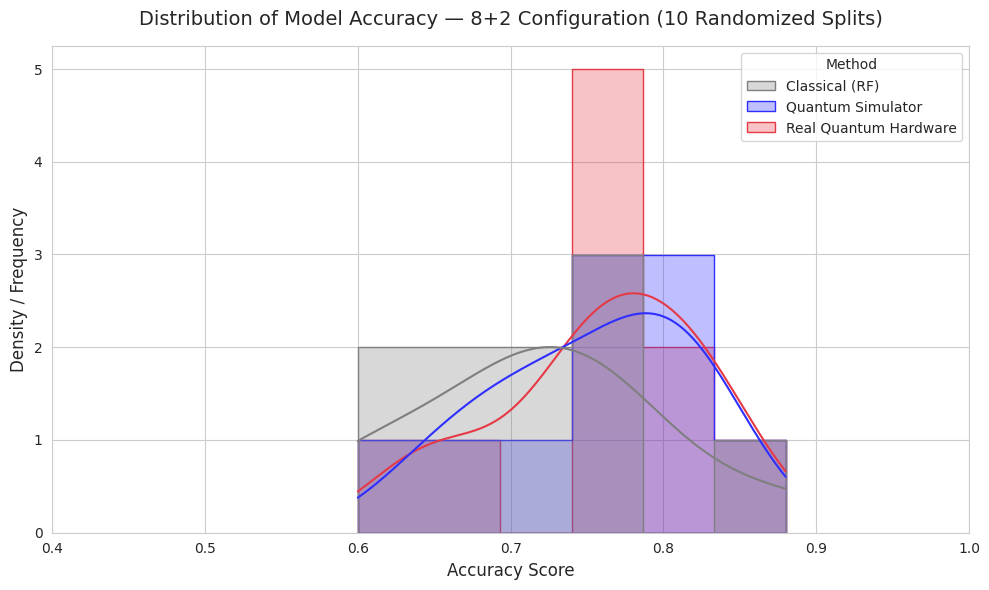


  Configuration: 8+2  |  N_QUBITS=10  |  Feature Vector Dim=2^10=1024
Method                    | Accuracy    | Precision   | Recall      | F1-Score    | AUC-ROC    
-----------------------------------------------------------------------------------------------
Classical (RF)            | 0.72 ± 0.08 | 0.71 ± 0.09 | 0.75 ± 0.11 | 0.73 ± 0.08 | 0.80 ± 0.06
Quantum Simulator         | 0.75 ± 0.07 | 0.76 ± 0.08 | 0.74 ± 0.07 | 0.75 ± 0.06 | 0.81 ± 0.08
Real Quantum Hardware     | 0.76 ± 0.07 | 0.76 ± 0.07 | 0.76 ± 0.08 | 0.76 ± 0.07 | 0.80 ± 0.07


In [ ]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from rdkit.Chem import AllChem

# Qiskit Imports
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
EN_MAP = {'H': 2.20, 'Li': 0.98, 'Be': 1.57, 'B': 2.04, 'C': 2.55,
          'N': 3.04, 'O': 3.44, 'F': 3.98, 'S': 2.58, 'Cl': 3.16}

ALPHA     = 0.1

# 8 backbone + 2 summary = 10 qubits total
N_EXACT   = 8
N_SUMMARY = 2
N_QUBITS  = N_EXACT + N_SUMMARY   # 10

SHOTS    = 8192
N_SPLITS = 10


# --- CORE FUNCTIONS ---
def qmse_8_plus_2(smiles):
    """
    QMSE feature map with 8+2 qubit allocation.
    - 8 backbone qubits (qubits 0–7): exact atomic mapping, θᵢ = α · χᵢ²
    - 2 summary qubits (qubits 8–9): alternating tail compression, θ = (α/2) · Σχ
    - Entanglement: ϕᵢⱼ = wᵢⱼ/2 applied uniformly to all bond cases
    Feature vector dimension: 2^10 = 1024
    """
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return QuantumCircuit(N_QUBITS)

    atoms = list(mol.GetAtoms())
    qc    = QuantumCircuit(N_QUBITS)

    # --- 1. BACKBONE ENCODING (Exact Atomic Mapping) ---
    # θᵢ = α · χᵢ²  for i ∈ {0, …, 7}
    # 8 atoms encoded exactly onto qubits 0–7
    backbone     = atoms[:N_EXACT]
    tail         = atoms[N_EXACT:]
    mol_to_qubit = {atom.GetIdx(): i for i, atom in enumerate(backbone)}

    for atom in backbone:
        en = EN_MAP.get(atom.GetSymbol(), 1.0)
        qc.ry(ALPHA * (en ** 2), mol_to_qubit[atom.GetIdx()])

    # --- 2. TAIL SUMMARY ENCODING (2-way Alternating Compression) ---
    # Tail atoms beyond position 8 split into alternating sets A and B
    # θ₈ = (α/2) · Σχₐ   (set A: even-indexed tail atoms → qubit 8)
    # θ₉ = (α/2) · Σχᵦ   (set B: odd-indexed tail atoms  → qubit 9)
    if tail:
        tail_sets = [[] for _ in range(N_SUMMARY)]
        for idx, atom in enumerate(tail):
            tail_sets[idx % N_SUMMARY].append(atom)

        for s_idx, t_set in enumerate(tail_sets):
            if t_set:
                agg_en = sum(EN_MAP.get(a.GetSymbol(), 1.0) for a in t_set)
                qc.ry((ALPHA / 2) * agg_en, N_EXACT + s_idx)

    # --- 3. TOPOLOGICAL ENTANGLEMENT (Bond Architecture) ---
    # ϕᵢⱼ = wᵢⱼ/2 applied uniformly to ALL bond cases
    # Summary qubits are 8 and 9
    summary_qubits = list(range(N_EXACT, N_QUBITS))   # [8, 9]

    for bond in mol.GetBonds():
        idx1, idx2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        q1, q2     = mol_to_qubit.get(idx1), mol_to_qubit.get(idx2)
        phi_ij     = bond.GetBondTypeAsDouble() / 2

        if q1 is not None and q2 is not None:
            # Backbone ↔ backbone: direct entanglement
            qc.rxx(phi_ij, q1, q2)
        elif q1 is not None:
            # Backbone → tail: symmetrically distributed to both summary qubits
            for sq in summary_qubits:
                qc.rxx(phi_ij, q1, sq)
        elif q2 is not None:
            # Tail → backbone: symmetrically distributed to both summary qubits
            for sq in summary_qubits:
                qc.rxx(phi_ij, q2, sq)

    qc.measure_all()
    return qc


def extract_features(pub_result, n_qubits=N_QUBITS):
    # 2^10 = 1024-dimensional feature vector
    counts = pub_result.data.meas.get_counts()
    p      = np.zeros(2 ** n_qubits)
    tot    = sum(counts.values())
    for k, v in counts.items():
        idx = int(k, 2) if isinstance(k, str) else k
        if idx < len(p):
            p[idx] = v / tot
    return p


# --- 1. DATA PREPARATION ---
print("Preparing BBBP Dataset (8+2 configuration)...")
df = pd.read_csv("https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv")
df = df.dropna(subset=['p_np', 'smiles'])
df = df[df['smiles'].apply(
    lambda s: Chem.MolFromSmiles(s) is not None and len(s) < 70
)]

n_sub    = 125
df_final = pd.concat([
    df[df['p_np'] == 1].sample(n_sub, random_state=42),
    df[df['p_np'] == 0].sample(n_sub, random_state=42)
]).sample(frac=1, random_state=42)

y           = df_final['p_np'].values
smiles_list = df_final['smiles'].values
circuits    = [qmse_8_plus_2(s) for s in smiles_list]

# --- 2. HARDWARE INITIALIZATION ---
token    = "API"
instance = "CRN"
try:
    QiskitRuntimeService.save_account(
        token=token, channel="ibm_cloud",
        instance=instance, name="Name", overwrite=True
    )
except:
    pass

service = QiskitRuntimeService(name="Name")
backend = service.backend("ibm_kingston")
print(f"Target Backend: {backend.name}")

# --- 3. FEATURE EXTRACTION ---

# A. Simulator
print("Running Simulator...")
aer_sampler = AerSampler()
X_sim = np.array([
    extract_features(p)
    for p in aer_sampler.run([(c,) for c in circuits], shots=SHOTS).result()
])

# B. Hardware (all 250 circuits submitted as one job)
print("Transpiling circuits for hardware...")
pm           = generate_preset_pass_manager(backend=backend, optimization_level=1, seed_transpiler=42)
isa_circuits = pm.run(circuits)
hw_sampler   = RuntimeSampler(mode=backend)

import time
max_retries = 3
for attempt in range(max_retries):
    try:
        hw_job = hw_sampler.run([(c,) for c in isa_circuits], shots=SHOTS)
        print(f"Hardware Job Submitted: {hw_job.job_id()}")
        X_hw = np.array([extract_features(pub) for pub in hw_job.result()])
        break
    except Exception as e:
        print(f"Attempt {attempt+1} failed: {e}")
        if attempt < max_retries - 1:
            print("Waiting 60 seconds before retry...")
            time.sleep(60)
        else:
            raise

# C. Classical (256-bit radius-2 Morgan fingerprints / ECFP4)
X_class = np.array([
    np.array(AllChem.GetMorganFingerprintAsBitVect(
        Chem.MolFromSmiles(s), 2, nBits=256
    ))
    for s in smiles_list
])

# --- 4. 10-SPLIT ANALYSIS ---
sss          = StratifiedShuffleSplit(n_splits=N_SPLITS, test_size=0.2, random_state=42)
results_list = []

for i, (train_idx, test_idx) in enumerate(sss.split(X_class, y)):
    y_test = y[test_idx]

    # Classical — Random Forest
    clf_c    = RandomForestClassifier(n_estimators=100).fit(X_class[train_idx], y[train_idx])
    y_pred_c = clf_c.predict(X_class[test_idx])
    y_prob_c = clf_c.predict_proba(X_class[test_idx])[:, 1]
    results_list.append({
        'Split': i, 'Method': 'Classical (RF)',
        'Accuracy':  accuracy_score(y_test, y_pred_c),
        'Precision': precision_score(y_test, y_pred_c, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_c, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred_c, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_c)
    })

    # Quantum Simulator — SVM RBF
    sc_s     = StandardScaler()
    clf_s    = SVC(kernel='rbf', C=10, probability=True).fit(
        sc_s.fit_transform(X_sim[train_idx]), y[train_idx]
    )
    X_sim_test = sc_s.transform(X_sim[test_idx])
    y_pred_s   = clf_s.predict(X_sim_test)
    y_prob_s   = clf_s.predict_proba(X_sim_test)[:, 1]
    results_list.append({
        'Split': i, 'Method': 'Quantum Simulator',
        'Accuracy':  accuracy_score(y_test, y_pred_s),
        'Precision': precision_score(y_test, y_pred_s, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_s, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred_s, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_s)
    })

    # Quantum Hardware — SVM RBF
    sc_h     = StandardScaler()
    clf_h    = SVC(kernel='rbf', C=10, probability=True).fit(
        sc_h.fit_transform(X_hw[train_idx]), y[train_idx]
    )
    X_hw_test = sc_h.transform(X_hw[test_idx])
    y_pred_h  = clf_h.predict(X_hw_test)
    y_prob_h  = clf_h.predict_proba(X_hw_test)[:, 1]
    results_list.append({
        'Split': i, 'Method': 'Real Quantum Hardware',
        'Accuracy':  accuracy_score(y_test, y_pred_h),
        'Precision': precision_score(y_test, y_pred_h, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_h, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred_h, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_h)
    })

# --- 5. VISUALIZATION ---
df_plot = pd.DataFrame(results_list)

palette = {
    'Classical (RF)':        '#7f7f7f',
    'Quantum Simulator':     '#2e2eff',
    'Real Quantum Hardware':  '#e63946'
}

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.histplot(
    data=df_plot, x='Accuracy', hue='Method',
    kde=True, element="step", palette=palette, alpha=0.3
)
plt.title('Distribution of Model Accuracy — 8+2 Configuration (10 Randomized Splits)',
          fontsize=14, pad=15)
plt.xlabel('Accuracy Score', fontsize=12)
plt.ylabel('Density / Frequency', fontsize=12)
plt.xlim(0.4, 1.0)
plt.tight_layout()
plt.show()

# --- 6. Table ---
print("\n" + "=" * 95)
print(f"  Configuration: 8+2  |  N_QUBITS={N_QUBITS}  |  Feature Vector Dim=2^{N_QUBITS}={2**N_QUBITS}")
print("=" * 95)
print(f"{'Method':25} | {'Accuracy':11} | {'Precision':11} | {'Recall':11} | {'F1-Score':11} | {'AUC-ROC':11}")
print("-" * 95)
for m in df_plot['Method'].unique():
    subset   = df_plot[df_plot['Method'] == m]
    acc_str  = f"{subset['Accuracy'].mean():.2f} ± {subset['Accuracy'].std():.2f}"
    prec_str = f"{subset['Precision'].mean():.2f} ± {subset['Precision'].std():.2f}"
    rec_str  = f"{subset['Recall'].mean():.2f} ± {subset['Recall'].std():.2f}"
    f1_str   = f"{subset['F1-Score'].mean():.2f} ± {subset['F1-Score'].std():.2f}"
    auc_str  = f"{subset['AUC-ROC'].mean():.2f} ± {subset['AUC-ROC'].std():.2f}"
    print(f"{m:25} | {acc_str:11} | {prec_str:11} | {rec_str:11} | {f1_str:11} | {auc_str:11}")
print("=" * 95)

#**CELL 6: 8(main qubits) + 4(summary qubits)**

Preparing BBBP Dataset (8+4 configuration)...


Target Backend: ibm_kingston
Running Simulator...
Transpiling circuits for hardware...
Hardware Job Submitted: d6uihuatnsts73es79ag


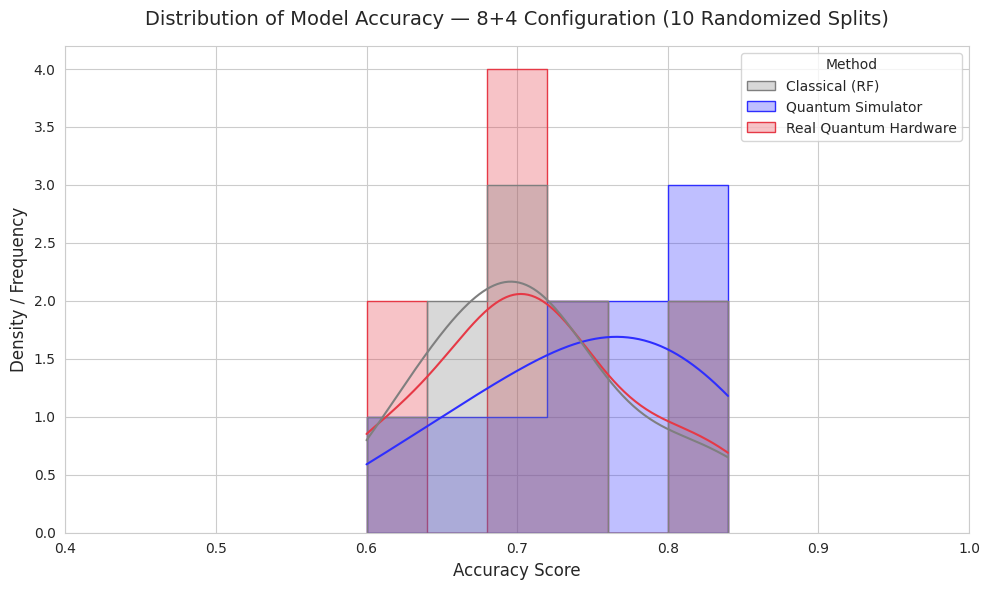


  Configuration: 8+4  |  N_QUBITS=12  |  Feature Vector Dim=2^12=4096
Method                    | Accuracy    | Precision   | Recall      | F1-Score    | AUC-ROC    
-----------------------------------------------------------------------------------------------
Classical (RF)            | 0.71 ± 0.07 | 0.71 ± 0.07 | 0.72 ± 0.11 | 0.71 ± 0.08 | 0.77 ± 0.05
Quantum Simulator         | 0.74 ± 0.08 | 0.75 ± 0.09 | 0.73 ± 0.08 | 0.74 ± 0.08 | 0.80 ± 0.08
Real Quantum Hardware     | 0.71 ± 0.07 | 0.70 ± 0.08 | 0.74 ± 0.07 | 0.72 ± 0.06 | 0.76 ± 0.08


In [ ]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from rdkit.Chem import AllChem

# Qiskit Imports
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
EN_MAP = {'H': 2.20, 'Li': 0.98, 'Be': 1.57, 'B': 2.04, 'C': 2.55,
          'N': 3.04, 'O': 3.44, 'F': 3.98, 'S': 2.58, 'Cl': 3.16}

ALPHA     = 0.1

# 8 backbone + 4 summary = 12 qubits total
N_EXACT   = 8
N_SUMMARY = 4
N_QUBITS  = N_EXACT + N_SUMMARY   # 12

SHOTS    = 8192
N_SPLITS = 10


# --- CORE FUNCTIONS ---
def qmse_8_plus_4(smiles):
    """
    QMSE feature map with 8+4 qubit allocation.
    - 8 backbone qubits (qubits 0–7): exact atomic mapping, θᵢ = α · χᵢ²
    - 4 summary qubits (qubits 8–11): 4-way alternating tail compression, θ = (α/2) · Σχ
    - Entanglement: ϕᵢⱼ = wᵢⱼ/2 applied uniformly to all bond cases
    Feature vector dimension: 2^12 = 4096
    """
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return QuantumCircuit(N_QUBITS)

    atoms = list(mol.GetAtoms())
    qc    = QuantumCircuit(N_QUBITS)

    # --- 1. BACKBONE ENCODING (Exact Atomic Mapping) ---
    # θᵢ = α · χᵢ²  for i ∈ {0, …, 7}
    # 8 atoms encoded exactly onto qubits 0–7
    backbone     = atoms[:N_EXACT]
    tail         = atoms[N_EXACT:]
    mol_to_qubit = {atom.GetIdx(): i for i, atom in enumerate(backbone)}

    for atom in backbone:
        en = EN_MAP.get(atom.GetSymbol(), 1.0)
        qc.ry(ALPHA * (en ** 2), mol_to_qubit[atom.GetIdx()])

    # --- 2. TAIL SUMMARY ENCODING (4-way Alternating Compression) ---
    # Tail atoms beyond position 8 distributed across 4 summary qubits
    # Set k receives tail atoms at indices: k, k+4, k+8, …
    # θ_{8+k} = (α/2) · Σχ for atoms in set k,  k ∈ {0,1,2,3}
    if tail:
        tail_sets = [[] for _ in range(N_SUMMARY)]
        for idx, atom in enumerate(tail):
            tail_sets[idx % N_SUMMARY].append(atom)

        for s_idx, t_set in enumerate(tail_sets):
            if t_set:
                agg_en = sum(EN_MAP.get(a.GetSymbol(), 1.0) for a in t_set)
                qc.ry((ALPHA / 2) * agg_en, N_EXACT + s_idx)

    # --- 3. TOPOLOGICAL ENTANGLEMENT (Bond Architecture) ---
    # ϕᵢⱼ = wᵢⱼ/2 applied uniformly to ALL bond cases
    # Summary qubits are 8, 9, 10, 11
    summary_qubits = list(range(N_EXACT, N_QUBITS))   # [8, 9, 10, 11]

    for bond in mol.GetBonds():
        idx1, idx2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        q1, q2     = mol_to_qubit.get(idx1), mol_to_qubit.get(idx2)
        phi_ij     = bond.GetBondTypeAsDouble() / 2

        if q1 is not None and q2 is not None:
            # Backbone ↔ backbone: direct entanglement
            qc.rxx(phi_ij, q1, q2)
        elif q1 is not None:
            # Backbone → tail: symmetrically distributed to all 4 summary qubits
            for sq in summary_qubits:
                qc.rxx(phi_ij, q1, sq)
        elif q2 is not None:
            # Tail → backbone: symmetrically distributed to all 4 summary qubits
            for sq in summary_qubits:
                qc.rxx(phi_ij, q2, sq)

    qc.measure_all()
    return qc


def extract_features(pub_result, n_qubits=N_QUBITS):
    # 2^12 = 4096-dimensional feature vector
    counts = pub_result.data.meas.get_counts()
    p      = np.zeros(2 ** n_qubits)
    tot    = sum(counts.values())
    for k, v in counts.items():
        idx = int(k, 2) if isinstance(k, str) else k
        if idx < len(p):
            p[idx] = v / tot
    return p


# --- 1. DATA PREPARATION ---
print("Preparing BBBP Dataset (8+4 configuration)...")
df = pd.read_csv("https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv")
df = df.dropna(subset=['p_np', 'smiles'])
df = df[df['smiles'].apply(
    lambda s: Chem.MolFromSmiles(s) is not None and len(s) < 70
)]

n_sub    = 125
df_final = pd.concat([
    df[df['p_np'] == 1].sample(n_sub, random_state=42),
    df[df['p_np'] == 0].sample(n_sub, random_state=42)
]).sample(frac=1, random_state=42)

y           = df_final['p_np'].values
smiles_list = df_final['smiles'].values
circuits    = [qmse_8_plus_4(s) for s in smiles_list]

# --- 2. HARDWARE INITIALIZATION ---
token    = "API"
instance = "CRN"
try:
    QiskitRuntimeService.save_account(
        token=token, channel="ibm_cloud",
        instance=instance, name="Name", overwrite=True
    )
except:
    pass

service = QiskitRuntimeService(name="Name")
backend = service.backend("ibm_kingston")
print(f"Target Backend: {backend.name}")

# --- 3. FEATURE EXTRACTION ---

# A. Simulator
print("Running Simulator...")
aer_sampler = AerSampler()
X_sim = np.array([
    extract_features(p)
    for p in aer_sampler.run([(c,) for c in circuits], shots=SHOTS).result()
])

# B. Hardware (all 250 circuits submitted as one job)
print("Transpiling circuits for hardware...")
pm           = generate_preset_pass_manager(backend=backend, optimization_level=1, seed_transpiler=42)
isa_circuits = pm.run(circuits)
hw_sampler   = RuntimeSampler(mode=backend)

import time
max_retries = 3
for attempt in range(max_retries):
    try:
        hw_job = hw_sampler.run([(c,) for c in isa_circuits], shots=SHOTS)
        print(f"Hardware Job Submitted: {hw_job.job_id()}")
        X_hw = np.array([extract_features(pub) for pub in hw_job.result()])
        break
    except Exception as e:
        print(f"Attempt {attempt+1} failed: {e}")
        if attempt < max_retries - 1:
            print("Waiting 60 seconds before retry...")
            time.sleep(60)
        else:
            raise

# C. Classical (256-bit radius-2 Morgan fingerprints / ECFP4)
X_class = np.array([
    np.array(AllChem.GetMorganFingerprintAsBitVect(
        Chem.MolFromSmiles(s), 2, nBits=256
    ))
    for s in smiles_list
])

# --- 4. 10-SPLIT ANALYSIS ---
sss          = StratifiedShuffleSplit(n_splits=N_SPLITS, test_size=0.2, random_state=42)
results_list = []

for i, (train_idx, test_idx) in enumerate(sss.split(X_class, y)):
    y_test = y[test_idx]

    # Classical — Random Forest
    clf_c    = RandomForestClassifier(n_estimators=100).fit(X_class[train_idx], y[train_idx])
    y_pred_c = clf_c.predict(X_class[test_idx])
    y_prob_c = clf_c.predict_proba(X_class[test_idx])[:, 1]
    results_list.append({
        'Split': i, 'Method': 'Classical (RF)',
        'Accuracy':  accuracy_score(y_test, y_pred_c),
        'Precision': precision_score(y_test, y_pred_c, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_c, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred_c, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_c)
    })

    # Quantum Simulator — SVM RBF
    sc_s     = StandardScaler()
    clf_s    = SVC(kernel='rbf', C=10, probability=True).fit(
        sc_s.fit_transform(X_sim[train_idx]), y[train_idx]
    )
    X_sim_test = sc_s.transform(X_sim[test_idx])
    y_pred_s   = clf_s.predict(X_sim_test)
    y_prob_s   = clf_s.predict_proba(X_sim_test)[:, 1]
    results_list.append({
        'Split': i, 'Method': 'Quantum Simulator',
        'Accuracy':  accuracy_score(y_test, y_pred_s),
        'Precision': precision_score(y_test, y_pred_s, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_s, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred_s, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_s)
    })

    # Quantum Hardware — SVM RBF
    sc_h     = StandardScaler()
    clf_h    = SVC(kernel='rbf', C=10, probability=True).fit(
        sc_h.fit_transform(X_hw[train_idx]), y[train_idx]
    )
    X_hw_test = sc_h.transform(X_hw[test_idx])
    y_pred_h  = clf_h.predict(X_hw_test)
    y_prob_h  = clf_h.predict_proba(X_hw_test)[:, 1]
    results_list.append({
        'Split': i, 'Method': 'Real Quantum Hardware',
        'Accuracy':  accuracy_score(y_test, y_pred_h),
        'Precision': precision_score(y_test, y_pred_h, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_h, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred_h, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_h)
    })

# --- 5. VISUALIZATION ---
df_plot = pd.DataFrame(results_list)

palette = {
    'Classical (RF)':        '#7f7f7f',
    'Quantum Simulator':     '#2e2eff',
    'Real Quantum Hardware':  '#e63946'
}

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.histplot(
    data=df_plot, x='Accuracy', hue='Method',
    kde=True, element="step", palette=palette, alpha=0.3
)
plt.title('Distribution of Model Accuracy — 8+4 Configuration (10 Randomized Splits)',
          fontsize=14, pad=15)
plt.xlabel('Accuracy Score', fontsize=12)
plt.ylabel('Density / Frequency', fontsize=12)
plt.xlim(0.4, 1.0)
plt.tight_layout()
plt.show()

# --- 6. Table ---
print("\n" + "=" * 95)
print(f"  Configuration: 8+4  |  N_QUBITS={N_QUBITS}  |  Feature Vector Dim=2^{N_QUBITS}={2**N_QUBITS}")
print("=" * 95)
print(f"{'Method':25} | {'Accuracy':11} | {'Precision':11} | {'Recall':11} | {'F1-Score':11} | {'AUC-ROC':11}")
print("-" * 95)
for m in df_plot['Method'].unique():
    subset   = df_plot[df_plot['Method'] == m]
    acc_str  = f"{subset['Accuracy'].mean():.2f} ± {subset['Accuracy'].std():.2f}"
    prec_str = f"{subset['Precision'].mean():.2f} ± {subset['Precision'].std():.2f}"
    rec_str  = f"{subset['Recall'].mean():.2f} ± {subset['Recall'].std():.2f}"
    f1_str   = f"{subset['F1-Score'].mean():.2f} ± {subset['F1-Score'].std():.2f}"
    auc_str  = f"{subset['AUC-ROC'].mean():.2f} ± {subset['AUC-ROC'].std():.2f}"
    print(f"{m:25} | {acc_str:11} | {prec_str:11} | {rec_str:11} | {f1_str:11} | {auc_str:11}")
print("=" * 95)